# **BLOCO 1**
# Modelos de Aprendizado de Máquina e Redes Neurais (Aula Prática)

Nesta aula vamos treinar **quatro modelos de Machine Learning**.
A ideia é sempre seguir o **mesmo padrão**:

1. Carregar o dataset  
2. Criar o modelo  
3. Treinar o modelo (`fit`)  
4. Fazer previsões (`predict`)  
5. Visualizar os resultados  

Modelos da aula:

- Regressão Linear
- Regressão Logística
- Árvore de Decisão
- K-Means

Experimente você mesmo (no final de cada modelo):
- Alterações do código: clicar na área de edição e alterar

Exercício com Redes Neurais (ex: MLP,CNN):
- Construir modelos de rede neurais para os problemas acima

Exercícios desafios (avançados):
- Incluir ajustes de hiperparâmetros (com validação cruzada) para redes neurais criadas
- Incluir métricas e visualizações adicionais para cada modelo criado
- Construir análise comparativa entre os modelos

**As atividades práticas não são avaliativas, mas devem ser entregues da seguinte forma para obtenção de feedback pelo monitor da disciplina:**
- Entregar arquivo ipynb ou link para notebook compartilhado para leitura
- O notebook deve incluir os resultados da execução, bem como explicações sobre os passos realizados   

# Importando bibliotecas

Usaremos apenas algumas bibliotecas simples.

In [64]:
import pandas as pd # importando biblioteca pandas, ja fizemos isso na ultima aula!
import matplotlib.pyplot as plt # importando biblioteca matplotlib, já fizemos isso na ultima aula!

from sklearn.model_selection import train_test_split # novidade aqui, importando o train_test_split
from sklearn.metrics import accuracy_score # outra novidade, importando o accuracy!

# 1️⃣ Regressão Linear

A regressão linear é usada para **prever números**.

Exemplo: prever o **preço de casas**.

Vamos usar o dataset **California Housing**. Esse dataset vem do censo da Califórnia de 1990 e cada linha representa uma pequena região dentro da California.

In [65]:
from sklearn.datasets import fetch_california_housing # vamos usar o dataset California Housing
from sklearn.linear_model import LinearRegression # vamos usar a regressão linear, que é um dos tipos de modelo de aprendizado de máquina

dataset_california_housing = fetch_california_housing(as_frame=True).frame # pega os dados (que não vem de um csv) e coloca em um dataframe pandas

In [66]:
# vamos entender melhor esses dados
dataset_california_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Explicação das colunas

- **MedInc** ->	renda média das famílias da região
- **HouseAge** ->	idade média das casas do bairro
- **AveRooms** ->	número médio de cômodos por casa
- **AveBedrms** ->	número médio de quartos de dormir
- **Population** ->	população total da região censitária
- **AveOccup** ->	média de moradores por residência
- **Latitude** ->	coordenada geográfica norte-sul
- **Longitude** ->	coordenada geográfica leste-oeste
- **MedHouseValue** ->	valor médio das casas da região em centenas de milhares de dólares

In [67]:
colunas_house = dataset_california_housing[["MedInc"]]   # vamos tentar prever o preço (nosso alvo) usando só a coluna/feature MedInc
alvo_house = dataset_california_housing["MedHouseVal"] # nosso alvo, o preço da casa

### Por que separar em treino e teste?

Imagine que você vai fazer uma prova amanhã.
Você passa a noite estudando as questões **da própria prova**.
No dia seguinte, acerta tudo — mas isso prova que você aprendeu ou só que memorizou?

Com modelos de Machine Learning é a mesma coisa.
Se treinarmos e avaliarmos o modelo nos **mesmos dados**, ele vai parecer ótimo
porque "decorou" as respostas... e vai falhar miseravelmente em dados novos.

Para evitar isso, dividimos os dados em dois grupos:

- **Treino**: os dados que o modelo vai usar para aprender
- **Teste**: dados que o modelo **nunca viu** durante o treino, usados apenas para avaliação

O `train_test_split` faz essa divisão automaticamente, de forma aleatória.

Uma divisão típica é **80% treino / 20% teste**, mas isso pode variar conforme o tamanho do dataset.

In [68]:
colunas_house

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [69]:
alvo_house

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [70]:
colunas_house_treino, colunas_house_teste, alvo_house_treino, alvo_house_teste = train_test_split(colunas_house, alvo_house, test_size=0.02) # divide em treino e teste. Teste só 1% do database

In [71]:
modelo_house = LinearRegression() # aqui estamos dizendo que queremos usar a Regressão Linear
modelo_house.fit(colunas_house_treino, alvo_house_treino) # a função fit é a que faz o treino, ou seja, momento que o modelo começa a aprender com os dados
pred = modelo_house.predict(colunas_house_teste) # com o modelo treinado, podemos predizer o valor das casas de teste

In [72]:
pred # valor das casas preditas de teste

array([1.92827878, 3.21645701, 2.65214136, 1.54753418, 2.08117094,
       1.5066011 , 1.42984111, 3.78855748, 1.81518964, 1.44063941,
       1.78534783, 2.13549726, 2.3639775 , 3.05732862, 3.32192875,
       1.7568035 , 1.99336154, 1.72926365, 2.85341659, 2.81168829,
       1.93221304, 1.62077844, 3.38588145, 3.16372114, 1.29996857,
       6.72699172, 1.08144954, 0.93445877, 1.22906812, 5.95169074,
       2.54516288, 2.07359539, 1.9258094 , 2.23690917, 1.27745119,
       1.30557699, 1.80359612, 1.47709412, 1.14644859, 3.27513613,
       2.34702669, 1.6717983 , 1.25740319, 2.6308796 , 2.17534214,
       1.76906668, 3.20971854, 0.84493336, 1.59461977, 1.56846111,
       1.52572831, 1.41527596, 1.93618916, 1.66786403, 2.21087607,
       1.8315545 , 1.18441005, 3.09926619, 2.07346983, 1.47776378,
       6.72699172, 2.65042535, 2.00018372, 1.1031717 , 1.51652046,
       1.83728848, 1.59081107, 1.96398012, 1.6815921 , 1.76195152,
       2.45936246, 2.38356511, 3.30439198, 2.63154926, 1.27778

### Avaliando

In [73]:
print("\nExemplos de previsão:\n")

for i in range(5):
    print("Valor real: $", alvo_house_teste.iloc[i])
    print("Valor predito: $", pred[i])
    print("----")


Exemplos de previsão:

Valor real: $ 1.581
Valor predito: $ 1.9282787775218286
----
Valor real: $ 3.932
Valor predito: $ 3.2164570089878843
----
Valor real: $ 2.464
Valor predito: $ 2.6521413583654647
----
Valor real: $ 3.773
Valor predito: $ 1.547534175154985
----
Valor real: $ 0.859
Valor predito: $ 2.0811709433397994
----


Quão bem foi o modelo? Para isso vamos usar o MAE. O MAE é o erro absoluto médio. É a média dos erros.

MAE = média(valor real−valor predito)



In [74]:
from sklearn.metrics import mean_absolute_error # importamos o MAE para poder usa-lo

erro = mean_absolute_error(alvo_house_teste, pred)
print("Erro médio absoluto:", erro)

Erro médio absoluto: 0.6411381713703134


#### Entendendo o resultado da avaliação

Esse erro médio mostra que o modelo erra em média $60.000 por predição que ele faz

## Visualizando a regressão

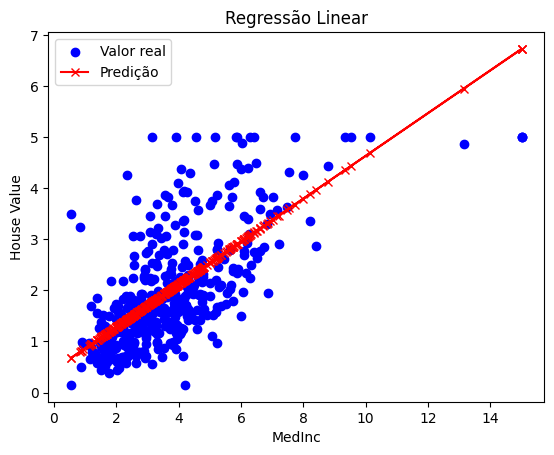

In [75]:
plt.scatter(colunas_house_teste, alvo_house_teste, color="blue", marker="o", label="Valor real") # scatter é o "gráfico de bolinhas". Dizemos a cor, o tipo de marcador e o rótulo (label)
plt.plot(colunas_house_teste, pred, color="red", marker="x", linestyle="-", label="Predição") # plot é o "gráfico de linha". Dizemos a cor, o marcador, tipo do tracejado e o rótulo (label)

plt.xlabel("MedInc")
plt.ylabel("House Value")
plt.title("Regressão Linear")
plt.legend()

plt.show()

### Dicas

- Para ver quais datasets temos disponiveis no sklearn, basta acessar esse link https://scikit-learn.org/stable/datasets.html

### Experimente você mesmo!

**1. Troque a feature e veja o impacto no erro:**
```python
# Tente usar "HouseAge" ou "AveRooms" no lugar de "MedInc" e compare o MAE
colunas_house = dataset_california_housing[["HouseAge"]]
```
R: Houve uma piora ao realizar essa troca, a dispersão ficou maior e o MAE subiu para 0.88

**2. Use duas features ao mesmo tempo:**
```python
# O modelo melhora quando damos mais informações para ele?
colunas_house = dataset_california_housing[["MedInc", "AveRooms"]]
```

R: Pouco, melhorou para 0.66, porém ainda é pior que o primeiro resultado.

**3. Aumente o tamanho do conjunto de teste:**
```python
# Troque test_size=0.01 por test_size=0.2 — as previsões tem melhores resultados?
train_test_split(colunas_house, alvo_house, test_size=0.2)
```

R: Não, houve uma leve piora

# 2️⃣ Regressão Logística

Apesar do nome, a regressão logística é usada para **classificação**.

Exemplo: prever se um tumor é **maligno ou benigno**.

Vamos usar o dataset **Breast Cancer**.

In [76]:
# importando as bibliotecas necessarias
from sklearn.datasets import load_breast_cancer # dataset cancer de mama
from sklearn.linear_model import LogisticRegression # modelo de regressão logística
from sklearn.metrics import accuracy_score # métricas nova: acurácia


In [77]:
dataset_breast_cancer = load_breast_cancer(as_frame=True).frame # carrega o dataset e transforma em um dataset pandas


In [78]:
dataset_breast_cancer.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [79]:
dataset_breast_cancer.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

### Explicação das colunas

- **mean radius** -> raio médio do tumor
- **mean texture** ->	variação média da textura
- **mean perimeter** ->	perímetro médio do tumor
- **mean area** ->	área média do tumor
- **mean smoothness** ->	suavidade média da borda
- **mean compactness** ->	densidade média da massa
- **mean concavity** ->	profundidade média das concavidades
- **target** -> câncer de mama (1) ou não (0)

In [80]:
# separar features e target. Daqui para frente chamaremos dessa maneira
#features = dataset_breast_cancer.drop(columns=["target"]) # features: todas as colunas do dataset, menos a coluna target
features = dataset_breast_cancer.drop(columns=["target"])
target = dataset_breast_cancer["target"] # target: a coluna que vai dizer se é cancer ou não

In [81]:
# separar em treino e teste
features_treino, features_teste, target_treino, target_teste = train_test_split(features, target, test_size=0.5) # 10% do nosso dataset vai ser usado para teste e os outros 90% para treinar o modelo

In [82]:
modelo_breast_cancer = LogisticRegression() # criando o modelo de Regressão Logística

In [83]:
modelo_breast_cancer.fit(features_treino, target_treino) # treino usando a função fit

C:\dev\unicamp\ia\atividade1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [84]:
pred = modelo_breast_cancer.predict(features_teste) # predição do set de teste usando a função predict

In [85]:
print("\nExemplos de previsão:\n")

for i in range(5):
    print("Valor real:", target_teste.iloc[i])
    print("Valor predito:", pred[i])
    print("-----")


Exemplos de previsão:

Valor real: 1
Valor predito: 1
-----
Valor real: 0
Valor predito: 0
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 1
-----


In [86]:
# acurácia
accuracy = accuracy_score(target_teste, pred)
print("Accuracy:", accuracy)

Accuracy: 0.9298245614035088


### Entendendo o resultado

A acurácia de X% significa que o modelo acertou **X% dos diagnósticos**.

Em outras palavras: uma acurácia de 94% siginifica que de cada 100 tumores analisados, ele errou apenas 6.

Para um problema médico, isso parece ótimo, mas cuidado: acurácia sozinha pode enganar.
Imagine um dataset onde 94% dos casos são benignos. Um modelo burro que sempre responde
"benigno" teria 94% de acurácia sem aprender nada.

Por isso, em problemas médicos costumamos usar métricas adicionais.

## Comparando previsões

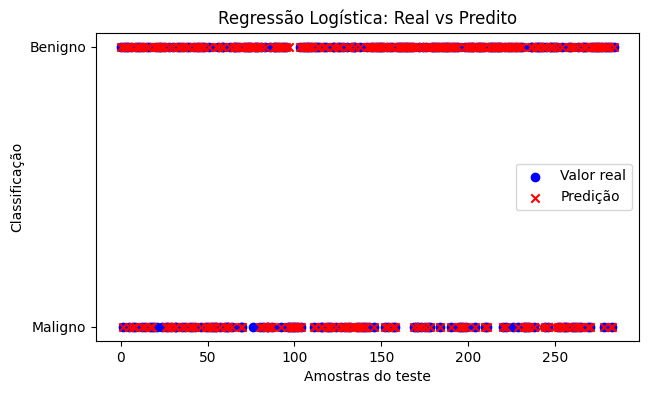

In [87]:
plt.figure(figsize=(7,4)) # figsize é o tamanho da figura

plt.scatter(range(len(target_teste)), target_teste,
            marker="o", color="blue", label="Valor real") # gráfico de pontos, marcador "bolinha", cor azul, para os valores reais do dataset

plt.scatter(range(len(pred)), pred,
            marker="x", color="red", label="Predição") # gráfico de pontos, marcador "em X", cor vermelha, para os valores que foram preditos pelo nosso modelo

plt.yticks([0,1], ["Maligno", "Benigno"])
plt.xlabel("Amostras do teste")
plt.ylabel("Classificação")
plt.title("Regressão Logística: Real vs Predito")

plt.legend()
plt.show()

### Explicando o Resultado

A regressão logística calcula a probabilidade de algo pertencer a uma classe.

Se a probabilidade passar de 50%, o modelo escolhe aquela classe.

Imagine um médico analisando um tumor.
Ele não pensa "é benigno ou maligno" imediatamente.

Ele pensa algo como:

*“Parece benigno com 80% de chance.”*

A regressão faz exatamente isso, mas usando matemática.

### Experimente você mesmo!

**1. Remova a coluna mais importante e veja a acurácia cair:**
```python
# "mean radius" é uma das features mais relevantes. O que acontece sem ela?
features = dataset_breast_cancer.drop(columns=["target", "mean radius"])
```
R: A acurácia caiu, indo de 94% para 92%

**2. Use metade dos dados para teste:**
```python
# O que acontece com a acurácia quando o modelo tem menos dados para treinar?
train_test_split(features, target, test_size=0.5)
```

R: A Acurácia se manteve em 92%

# 3️⃣ Árvore de Decisão

Árvores de decisão funcionam como **fluxogramas de decisão**.

Vamos usar novamente o dataset **Titanic**.

In [88]:
from sklearn.tree import DecisionTreeClassifier # importa a biblioteca de Árvore de Decisão

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
dataset_titanic = pd.read_csv(url)
dataset_titanic = dataset_titanic[["Pclass","Sex","Age","Fare","Survived"]] # escolhe quais colunas do Titanic vai usar

In [89]:
dataset_titanic.head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [90]:
print("Valores faltantes por coluna:\n")
print(dataset_titanic.isnull().sum())

Valores faltantes por coluna:

Pclass        0
Sex           0
Age         177
Fare          0
Survived      0
dtype: int64


In [91]:
dataset_titanic["Sex"] = dataset_titanic["Sex"].map({"male":0,"female":1}) # aqui deixamos o valor 0 como masculino e 1 como feminino. A árvore de decisão não entende "palavras" aqui

In [92]:
dataset_titanic = dataset_titanic.dropna() # remove todas as linhas que estão vazias, ou seja, todas as linhas que tem alguém sem idade

In [93]:
dataset_titanic.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [94]:
features = dataset_titanic[["Pclass","Age","Fare"]] # define quais são nossas features
target = dataset_titanic["Survived"] # define qual é nosso target

In [95]:
features_treino, features_teste, target_treino, target_teste = train_test_split(features, target, test_size=0.2) # divide em treino (80%) e teste (20%)

In [96]:
modelo_titanic = DecisionTreeClassifier(max_depth=5) # aqui diz que usaremos uma árvore de classificação com profundidade 3

In [97]:
modelo_titanic.fit(features_treino, target_treino) # treina o modelo

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [98]:
pred = modelo_titanic.predict(features_teste) # faz as predições

In [99]:
print("\nExemplos de previsão:\n")

for i in range(5):
    print("Valor real:", target_teste.iloc[i])
    print("Valor predito:", pred[i])
    print("-----")


Exemplos de previsão:

Valor real: 0
Valor predito: 0
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 0
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 1
-----


In [100]:
accuracy = accuracy_score(target_teste, pred)
print("\nAccuracy:", accuracy)


Accuracy: 0.7692307692307693


## Visualizando previsões

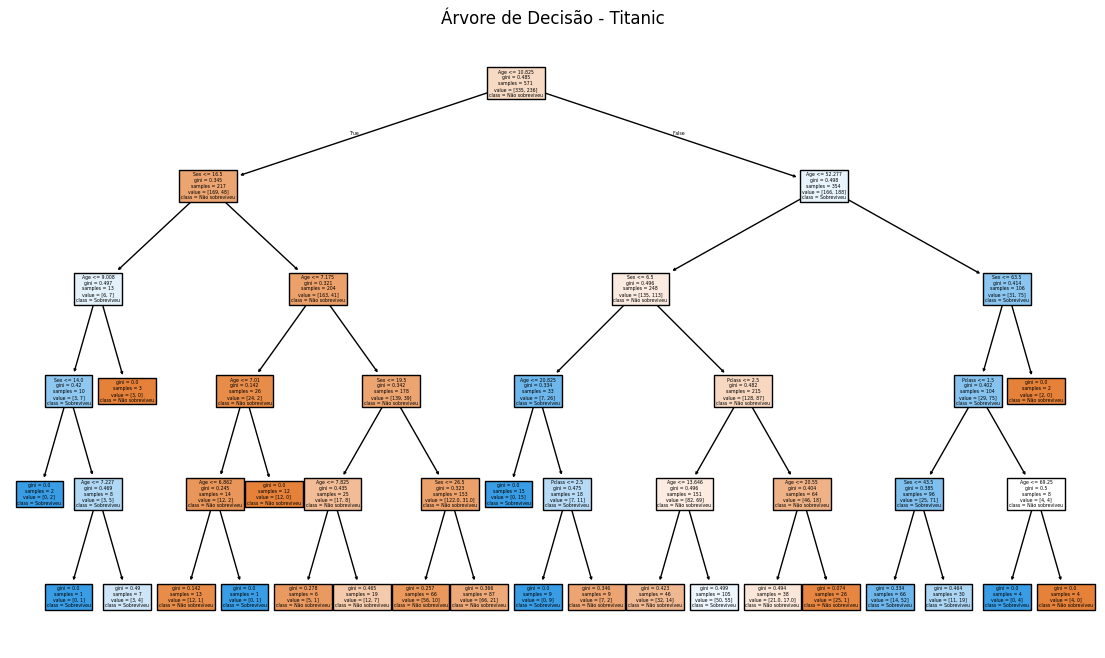

In [101]:
from sklearn import tree
plt.figure(figsize=(14,8))

tree.plot_tree(
    modelo_titanic,
    feature_names=["Pclass","Sex","Age","Fare"],
    class_names=["Não sobreviveu","Sobreviveu"],
    filled=True
)

plt.title("Árvore de Decisão - Titanic")
plt.show()

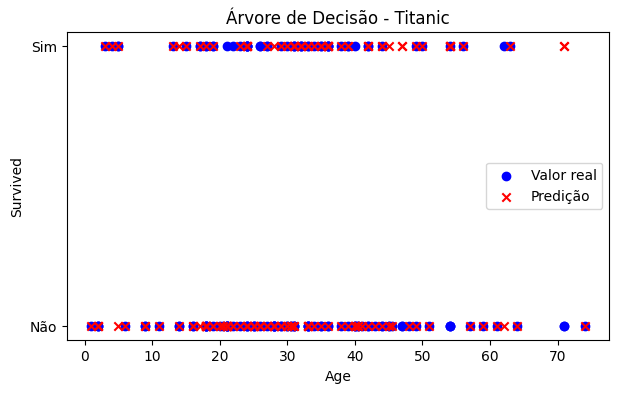

In [102]:
plt.figure(figsize=(7,4))

plt.scatter(features_teste["Age"], target_teste,
            color="blue", marker="o", label="Valor real")

plt.scatter(features_teste["Age"], pred,
            color="red", marker="x", label="Predição")

plt.xlabel("Age")
plt.ylabel("Survived")
plt.yticks([0,1], ["Não", "Sim"])
plt.title("Árvore de Decisão - Titanic")

plt.legend()
plt.show()

### Experimente você mesmo!

**1. Mude a profundidade da árvore:**
```python
# Tente max_depth=1, max_depth=5 e max_depth=10 — o que acontece com a acurácia?
# Dica: uma árvore muito profunda "decora" os dados de treino e vai mal no teste
modelo_titanic = DecisionTreeClassifier(max_depth=1)
```

Max_depth 1 -> Acurácia 79%
Max_depth 5 -> Acurácia 85%
Max_depth 10 -> Acurácia 85%

Acima de depth 5 não houve ganho considerável de precisão


**2. Remova a coluna "Sex" e veja o impacto:**
```python
# Sexo foi um critério real de embarque nos botes salva-vidas.
# O modelo piora muito sem essa informação?
features = dataset_titanic[["Pclass", "Age", "Fare"]]
```

Sim, a acurácia caiu para 67%

**3. Plote a árvore com profundidade 1 — fica pequena e fácil de ler:**
```python
modelo_titanic_simples = DecisionTreeClassifier(max_depth=1)
modelo_titanic_simples.fit(features_treino, target_treino)

tree.plot_tree(
    modelo_titanic_simples,
    feature_names=["Pclass", "Sex", "Age", "Fare"],
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True
)
plt.show()
```

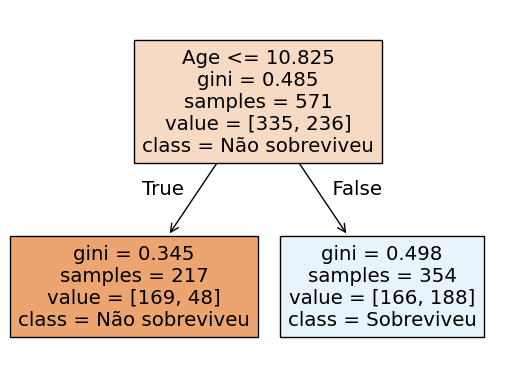

In [103]:
modelo_titanic_simples = DecisionTreeClassifier(max_depth=1)
modelo_titanic_simples.fit(features_treino, target_treino)

tree.plot_tree(
    modelo_titanic_simples,
    feature_names=["Pclass", "Sex", "Age", "Fare"],
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True
)
plt.show()

# 4️⃣ K-Means (Clustering)

Diferente dos outros modelos, o **K-Means não usa rótulos**.

Ele tenta **descobrir grupos automaticamente** nos dados.

In [104]:
from sklearn.datasets import load_iris # caregga o dataset IRIS
from sklearn.cluster import KMeans # carrega o modelo KMeans

dataset_iris = load_iris(as_frame=True).frame # transforma o dataset IRIS em um dataset pandas

In [105]:
dataset_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Explicação das colunas

- **sepal length (cm):**	comprimento da sépala da flor
- **sepal width (cm):**	largura da sépala da flor
- **petal length (cm):**	comprimento da pétala
- **petal width (cm)**	largura da pétala
- **target:**	espécie da flor (0 → Setosa; 1 → Versicolor; 2 → Virginica)

In [106]:
features = dataset_iris.drop(columns=["target"]) # nossas features: todas as colunas, exceto o target, ou seja, sepal length, sepal width, petal length, petal width
target = dataset_iris["target"] # coluna target aqui é a espécie da flor

In [107]:
modelo_kmeans = KMeans(n_clusters=5) # estamos dizendo que queremos usar o K Means e formar 3 grupos

In [108]:
# treino
modelo_kmeans.fit(features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [109]:
# prever clusters
pred = modelo_kmeans.predict(features)

In [110]:
print("\nExemplos de clusterização:\n")

for i in range(5):
    print("Classe real:", target.iloc[i])
    print("Cluster encontrado:", pred[i])
    print("-----")


Exemplos de clusterização:

Classe real: 0
Cluster encontrado: 0
-----
Classe real: 0
Cluster encontrado: 0
-----
Classe real: 0
Cluster encontrado: 0
-----
Classe real: 0
Cluster encontrado: 0
-----
Classe real: 0
Cluster encontrado: 0
-----


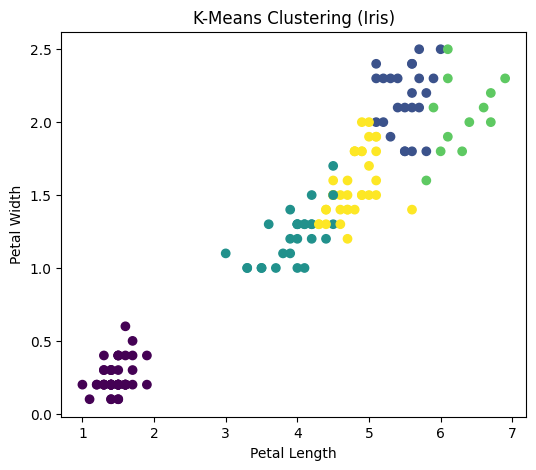

In [111]:
plt.figure(figsize=(6,5))

plt.scatter(
    features["petal length (cm)"],
    features["petal width (cm)"],
    c=pred,
    cmap="viridis",
    marker="o"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering (Iris)")

plt.show()

## Visualizando os clusters

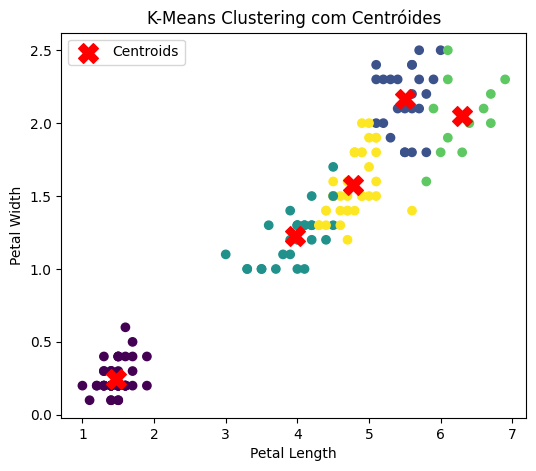

In [112]:
centroids = modelo_kmeans.cluster_centers_

plt.figure(figsize=(6,5))

plt.scatter(
    features["petal length (cm)"],
    features["petal width (cm)"],
    c=pred,
    cmap="viridis",
    marker="o"
)

plt.scatter(
    centroids[:,2],
    centroids[:,3],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering com Centróides")

plt.legend()
plt.show()

### 🧪 Experimente você mesmo!

**1. Mude o número de clusters:**
```python
# O que acontece quando pedimos 2 grupos? E 5 grupos?
# O modelo vai tentar se virar de qualquer jeito — mas vai fazer sentido?
modelo_kmeans = KMeans(n_clusters=2)
```

R: Com dois grupos as divisões ficam evidentes e afastadas. Com 5 grupos alguns deles chegam a se sobrepor, não fazendo muito sentido a classificação

# Conclusão e próximos passos

Treinamos quatro modelos:
- **Regressão Linear**
- **Regressão Logística**
- **Árvore de Decisão**
- **K-Means**

Todos seguem o mesmo padrão:

model = Modelo()  
model.fit(X, y)  
model.predict(X)

# Incluir abaixo
Exercício com Redes Neurais (MLP ou CNN):
- **Construir modelos de rede neurais para os problemas acima**

Exercícios desafios (avançados):

-	**Incluir ajustes de hiperparâmetros (com validação cruzada) para cada rede neural**
-	**Incluir métricas e visualizações adicionais para cada modelo criado**
-	**Construir análise comparativa entre os modelos**

# Importante
As atividades práticas não são avaliativas, mas devem ser entregues da seguinte forma para obtenção de feedback pelo monitor da disciplina:
- **Entregar arquivo ipynb ou link para notebook compartilhado para leitura**
- **O notebook deve incluir os resultados da execução, bem como explicações sobre os passos realizados**



# Exercício com MLP

Carrega o dataset do titanic e mostra os dados

In [113]:
from sklearn.neural_network import MLPClassifier # importa a biblioteca de MLP
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
dataset_titanic = pd.read_csv(url)
dataset_titanic = dataset_titanic[["Pclass","Sex","Age","Fare","Survived"]] # escolhe quais colunas do Titanic vai usar
dataset_titanic["Sex"] = dataset_titanic["Sex"].map({"male":0,"female":1})
dataset_titanic = dataset_titanic.dropna()
dataset_titanic.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [114]:
features = dataset_titanic[["Pclass", "Sex", "Age", "Fare"]]  # define quais são nossas features
target = dataset_titanic["Survived"]  # define qual é nosso target
features_treino, features_teste, target_treino, target_teste = train_test_split(features, target,
                                                                                test_size=0.2)  # divide em treino (80%) e teste (20%)

# MLP Depende de Scaler para ser executado

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
feature_treino_scaled = scaler.fit_transform(features_treino)
feature_teste_scaled = scaler.transform(features_teste)

# Ajuste de hiper parâmetros de treino
O melhor resultado que consegui chegar foi em 79.7% com hidden_layer_size=(100,50)

In [123]:
modelo_titanic = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42, activation='relu', early_stopping=True)
modelo_titanic.fit(feature_treino_scaled, target_treino)  # treino

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [124]:
precisao = modelo_titanic.score(feature_teste_scaled, target_teste)
print(f"Acurácia: {precisao:.6f}")

Acurácia: 0.804196


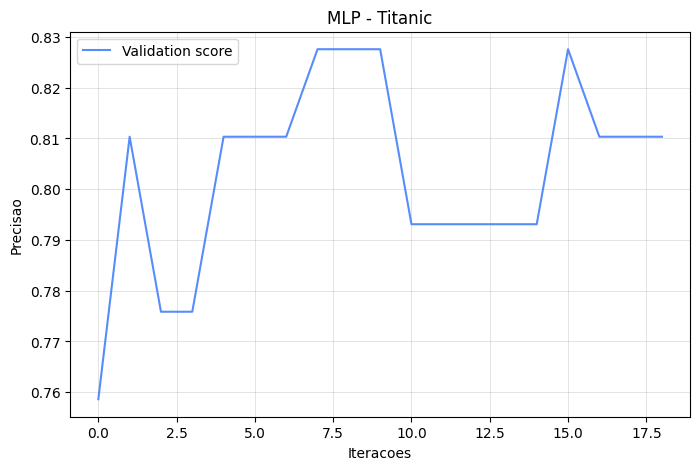

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(modelo_titanic.validation_scores_, label="Validation score")
plt.xlabel("Iteracoes")
plt.ylabel("Precisao")
plt.legend()
plt.grid(True)
plt.title("MLP - Titanic")
plt.show()